In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv("/Users/berkecelik/Downloads/logistic_regression_data_expanded.csv")

X_train = data[["feature1", "feature2"]].values
y_train = data["label"].values

m, n = X_train.shape

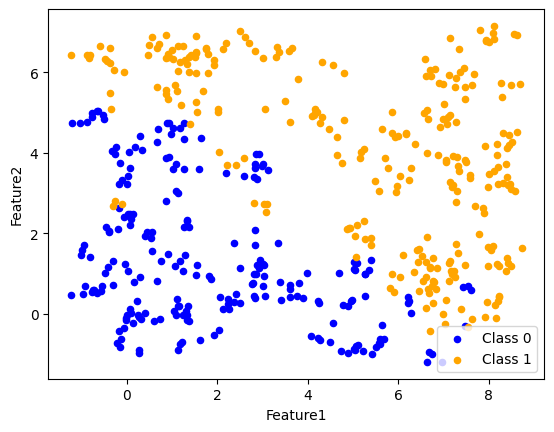

In [15]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color = "blue", label = "Class 0", s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color = "orange", label = "Class 1", s = 20)
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [18]:
def cost_function(X, y, w, b):
    cost_sum = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1 / m) * cost_sum

In [19]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w += (g - y[i]) * X[i, j]

    grad_b = (1 / m) * grad_b
    grad_w = (1 / m) * grad_w

    return grad_b, grad_w


In [20]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}")

    return w, b


In [21]:
def predict(X, w, b):
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds

In [22]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)

predictions = predict(X_train, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6632794342149954
Iteration 1000: Cost 0.41210435754766006
Iteration 2000: Cost 0.34424573316566043
Iteration 3000: Cost 0.30842058093985536
Iteration 4000: Cost 0.28637629479598725
Iteration 5000: Cost 0.2714405394548568
Iteration 6000: Cost 0.26064975020735137
Iteration 7000: Cost 0.2524916504639881
Iteration 8000: Cost 0.24611322399781677
Iteration 9000: Cost 0.2409959349488089
Training accuracy: 91.80%


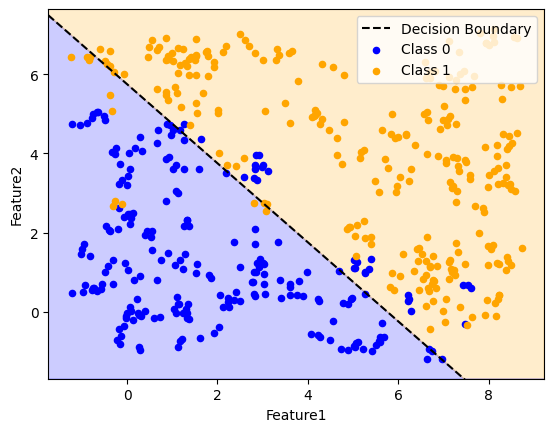

In [23]:
m = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.plot(xd, yd, "k", ls = "--", label = "Decision Boundary")
plt.fill_between(xd, yd, ymin, color = "blue", alpha = 0.2)
plt.fill_between(xd, yd, ymax, color = "orange", alpha = 0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color = "blue", label = "Class 0", s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color = "orange", label = "Class 1", s = 20)
plt.legend()
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()